# Factor Analysis for S&P 500 Stock Selection

This notebook demonstrates how to implement a multi-factor stock selection model for the S&P 500. Factor investing is based on the premise that stocks with certain characteristics (factors) tend to outperform the broader market over time.

In this notebook, we'll cover:

1. Factor model theory and implementation
2. Analyzing traditional factors: Value, Momentum, Quality, Size, Volatility
3. Building a composite factor ranking system
4. Backtesting factor-based portfolios
5. Performance attribution and factor timing
6. Adaptive factor allocation methods

## Setup and Data Collection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
import datetime as dt

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

Let's define the S&P 500 stocks we'll analyze. For simplicity and computation efficiency, we'll use a subset of the S&P 500 constituents representing different sectors.

In [ ]:
# Define a subset of S&P 500 stocks representing different sectors
# Note: In a full implementation, you would use all S&P 500 constituents
stocks = {
    # Technology
    'AAPL': 'Apple Inc.',
    'MSFT': 'Microsoft Corporation',
    'NVDA': 'NVIDIA Corporation',
    'GOOGL': 'Alphabet Inc.',
    'META': 'Meta Platforms, Inc.',
    
    # Healthcare
    'JNJ': 'Johnson & Johnson',
    'PFE': 'Pfizer Inc.',
    'UNH': 'UnitedHealth Group Incorporated',
    'ABBV': 'AbbVie Inc.',
    'MRK': 'Merck & Co., Inc.',
    
    # Financial
    'JPM': 'JPMorgan Chase & Co.',
    'BAC': 'Bank of America Corporation',
    'WFC': 'Wells Fargo & Company',
    'C': 'Citigroup Inc.',
    'GS': 'The Goldman Sachs Group, Inc.',
    
    # Consumer Discretionary
    'AMZN': 'Amazon.com, Inc.',
    'TSLA': 'Tesla, Inc.',
    'HD': 'The Home Depot, Inc.',
    'MCD': 'McDonald\'s Corporation',
    'NKE': 'NIKE, Inc.',
    
    # Consumer Staples
    'PG': 'The Procter & Gamble Company',
    'KO': 'The Coca-Cola Company',
    'PEP': 'PepsiCo, Inc.',
    'WMT': 'Walmart Inc.',
    'COST': 'Costco Wholesale Corporation',
    
    # Industrials
    'GE': 'General Electric Company',
    'BA': 'The Boeing Company',
    'UPS': 'United Parcel Service, Inc.',
    'HON': 'Honeywell International Inc.',
    'CAT': 'Caterpillar Inc.',
    
    # Energy
    'XOM': 'Exxon Mobil Corporation',
    'CVX': 'Chevron Corporation',
    'COP': 'ConocoPhillips',
    'EOG': 'EOG Resources, Inc.',
    'SLB': 'Schlumberger Limited',
    
    # Utilities
    'NEE': 'NextEra Energy, Inc.',
    'DUK': 'Duke Energy Corporation',
    'SO': 'The Southern Company',
    'D': 'Dominion Energy, Inc.',
    'AEP': 'American Electric Power Company, Inc.',
    
    # Materials
    'LIN': 'Linde plc',
    'FCX': 'Freeport-McMoRan Inc.',
    'APD': 'Air Products and Chemicals, Inc.',
    'ECL': 'Ecolab Inc.',
    'NEM': 'Newmont Corporation',
    
    # Communication Services
    'NFLX': 'Netflix, Inc.',
    'CMCSA': 'Comcast Corporation',
    'VZ': 'Verizon Communications Inc.',
    'T': 'AT&T Inc.',
    'DIS': 'The Walt Disney Company'
}

# Define sectors for each stock
sectors = {
    'AAPL': 'Technology', 'MSFT': 'Technology', 'NVDA': 'Technology', 'GOOGL': 'Technology', 'META': 'Technology',
    'JNJ': 'Healthcare', 'PFE': 'Healthcare', 'UNH': 'Healthcare', 'ABBV': 'Healthcare', 'MRK': 'Healthcare',
    'JPM': 'Financial', 'BAC': 'Financial', 'WFC': 'Financial', 'C': 'Financial', 'GS': 'Financial',
    'AMZN': 'Consumer Discretionary', 'TSLA': 'Consumer Discretionary', 'HD': 'Consumer Discretionary', 
    'MCD': 'Consumer Discretionary', 'NKE': 'Consumer Discretionary',
    'PG': 'Consumer Staples', 'KO': 'Consumer Staples', 'PEP': 'Consumer Staples', 
    'WMT': 'Consumer Staples', 'COST': 'Consumer Staples',
    'GE': 'Industrials', 'BA': 'Industrials', 'UPS': 'Industrials', 'HON': 'Industrials', 'CAT': 'Industrials',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'EOG': 'Energy', 'SLB': 'Energy',
    'NEE': 'Utilities', 'DUK': 'Utilities', 'SO': 'Utilities', 'D': 'Utilities', 'AEP': 'Utilities',
    'LIN': 'Materials', 'FCX': 'Materials', 'APD': 'Materials', 'ECL': 'Materials', 'NEM': 'Materials',
    'NFLX': 'Communication Services', 'CMCSA': 'Communication Services', 'VZ': 'Communication Services', 
    'T': 'Communication Services', 'DIS': 'Communication Services'
}

# Download 5 years of data for these stocks
stock_data = yf.download(list(stocks.keys()), period='5y', group_by='ticker', auto_adjust=False)

# Verify the data
print(f"Data period: {stock_data.index[0].date()} to {stock_data.index[-1].date()}")
print(f"Number of stocks: {len(stocks)}")
print(f"Number of trading days: {len(stock_data)}")

[*********************100%***********************]  50 of 50 completed


Data period: 2020-05-04 to 2025-05-01
Number of stocks: 50
Number of trading days: 1256


In [ ]:
# Organize the data: Create a dictionary of DataFrames for each stock
stock_dfs = {}
for ticker in stocks.keys():
    stock_dfs[ticker] = pd.DataFrame({
        'Open': stock_data[ticker]['Open'],
        'High': stock_data[ticker]['High'],
        'Low': stock_data[ticker]['Low'],
        'Close': stock_data[ticker]['Close'],
        'Adj Close': stock_data[ticker]['Adj Close'],
        'Volume': stock_data[ticker]['Volume']
    })
    
    # Add returns
    stock_dfs[ticker]['Returns'] = stock_dfs[ticker]['Adj Close'].pct_change()
    stock_dfs[ticker]['Log_Returns'] = np.log(stock_dfs[ticker]['Adj Close'] / stock_dfs[ticker]['Adj Close'].shift(1))
    
# Create a DataFrame with all stock prices
prices = pd.DataFrame({ticker: df['Adj Close'] for ticker, df in stock_dfs.items()})

# Create a DataFrame with all stock returns
returns = pd.DataFrame({ticker: df['Returns'] for ticker, df in stock_dfs.items()})

# Check the data
print("Price data sample:")
display(prices.head())

print("\nReturns data sample:")
display(returns.head())

Price data sample:


,AAPL,MSFT,NVDA,GOOGL,META,JNJ,PFE,UNH,ABBV,MRK,...,LIN,FCX,APD,ECL,NEM,NFLX,CMCSA,VZ,T,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-04,71.143791,171.181839,7.255518,65.830269,204.297150,128.857864,28.634890,267.182007,66.699028,62.905537,...,170.107010,8.198649,198.316849,181.488785,53.370018,428.149994,31.775787,42.155441,15.556800,101.920906
2020-05-05,72.211578,173.019592,7.316543,67.130051,206.098663,129.926788,29.312325,272.292572,69.558968,63.846737,...,169.501724,8.292887,199.160370,183.194504,55.215946,424.679993,31.626646,42.357822,15.630379,99.826775
2020-05-06,72.956596,174.723389,7.417421,66.951408,207.492081,128.692719,29.312325,268.324890,69.599701,63.118317,...,166.652008,8.094989,198.343475,182.919647,53.106312,434.260010,30.828304,41.705700,15.131091,99.648972
2020-05-07,73.711342,175.738022,7.593773,68.138237,210.268997,128.266861,28.412882,264.821747,68.621948,61.874275,...,172.090652,8.453089,201.380173,183.952560,54.918209,436.529999,31.214317,41.660740,15.183646,104.281738
2020-05-08,75.465775,176.771759,7.783822,68.887657,211.353897,129.231552,28.612759,266.680176,68.410103,62.529034,...,175.461853,8.679260,207.311462,187.401947,54.909698,435.549988,32.047749,42.725109,15.656658,107.827934



Returns data sample:


,AAPL,MSFT,NVDA,GOOGL,META,JNJ,PFE,UNH,ABBV,MRK,...,LIN,FCX,APD,ECL,NEM,NFLX,CMCSA,VZ,T,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-05,0.015009,0.010736,0.008411,0.019744,0.008818,0.008295,0.023658,0.019128,0.042878,0.014962,...,-0.003558,0.011494,0.004253,0.009398,0.034587,-0.008105,-0.004694,0.004801,0.004730,-0.020547
2020-05-06,0.010317,0.009847,0.013788,-0.002661,0.006761,-0.009498,0.000000,-0.014571,0.000586,-0.011409,...,-0.016812,-0.023864,-0.004102,-0.001500,-0.038207,0.022558,-0.025243,-0.015396,-0.031943,-0.001781
2020-05-07,0.010345,0.005807,0.023775,0.017727,0.013383,-0.003309,-0.030685,-0.013056,-0.014048,-0.019710,...,0.032635,0.044237,0.015310,0.005647,0.034118,0.005227,0.012521,-0.001078,0.003473,0.046491
2020-05-08,0.023801,0.005882,0.025027,0.010999,0.005160,0.007521,0.007035,0.007018,-0.003087,0.010582,...,0.019590,0.026756,0.029453,0.018752,-0.000155,-0.002245,0.026700,0.025548,0.031153,0.034006


[*********************100%***********************]  1 of 1 completed


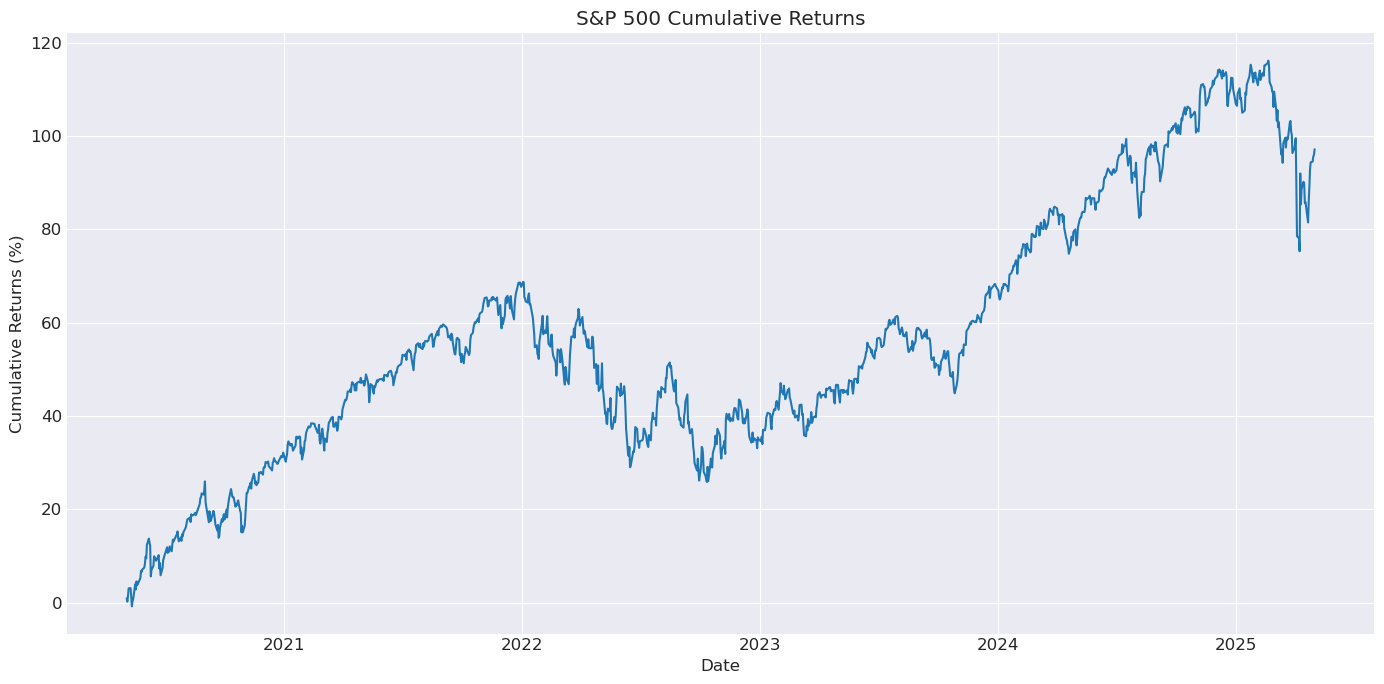

In [ ]:
# Download S&P 500 index data for benchmarking
sp500 = yf.download('^GSPC', auto_adjust=False, period='5y')
sp500['Returns'] = sp500['Adj Close'].pct_change()

# Create a column for cumulative returns
sp500['Cumulative_Returns'] = (1 + sp500['Returns']).cumprod() - 1

# Plot S&P 500 performance over the period
plt.figure(figsize=(14, 7))
plt.plot(sp500.index, sp500['Cumulative_Returns'] * 100)
plt.title('S&P 500 Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Factor Data Collection

Now, let's collect fundamental data for our factor analysis. In a production environment, you'd use a specialized financial data provider like Bloomberg, Refinitiv, or FactSet for accurate fundamental data. For this notebook, we'll use Yahoo Finance to demonstrate the concepts.

In [ ]:
def get_fundamentals(ticker):
    """Get fundamental data for a stock"""
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        # Financial ratios
        pe_ratio = info.get('trailingPE', np.nan)
        pb_ratio = info.get('priceToBook', np.nan)
        ps_ratio = info.get('priceToSalesTrailing12Months', np.nan)
        peg_ratio = info.get('pegRatio', np.nan)
        ev_to_ebitda = info.get('enterpriseToEbitda', np.nan)
        
        # Profitability metrics
        roe = info.get('returnOnEquity', np.nan)
        roa = info.get('returnOnAssets', np.nan)
        profit_margin = info.get('profitMargins', np.nan)
        operating_margin = info.get('operatingMargins', np.nan)
        ebitda_margins = info.get('ebitdaMargins', np.nan)
        
        # Growth metrics
        revenue_growth = info.get('revenueGrowth', np.nan)
        earnings_growth = info.get('earningsGrowth', np.nan)
        free_cash_flow = info.get('freeCashflow', np.nan)
        
        # Size and liquidity metrics
        market_cap = info.get('marketCap', np.nan)
        beta = info.get('beta', np.nan)
        shares_outstanding = info.get('sharesOutstanding', np.nan)
        avg_volume = info.get('averageVolume', np.nan)
        debt_to_equity = info.get('debtToEquity', np.nan)
        current_ratio = info.get('currentRatio', np.nan)
        dividend_yield = info.get('dividendYield', np.nan) if info.get('dividendYield') else 0
        
        # Compile results
        fundamentals = {
            'PE_Ratio': pe_ratio,
            'PB_Ratio': pb_ratio,
            'PS_Ratio': ps_ratio,
            'PEG_Ratio': peg_ratio,
            'EV_to_EBITDA': ev_to_ebitda,
            'ROE': roe,
            'ROA': roa,
            'Profit_Margin': profit_margin,
            'Operating_Margin': operating_margin,
            'EBITDA_Margin': ebitda_margins,
            'Revenue_Growth': revenue_growth,
            'Earnings_Growth': earnings_growth,
            'Free_Cash_Flow': free_cash_flow,
            'Market_Cap': market_cap,
            'Beta': beta,
            'Shares_Outstanding': shares_outstanding,
            'Avg_Volume': avg_volume,
            'Debt_to_Equity': debt_to_equity,
            'Current_Ratio': current_ratio,
            'Dividend_Yield': dividend_yield
        }
        
        return fundamentals
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return {}

# Collect fundamental data for all stocks
fundamental_data = {}
for ticker in stocks.keys():
    print(f"Fetching fundamental data for {ticker}...")
    fundamental_data[ticker] = get_fundamentals(ticker)

# Convert to DataFrame
fundamentals_df = pd.DataFrame.from_dict(fundamental_data, orient='index')
fundamentals_df.index.name = 'Ticker'

# Add sector information
fundamentals_df['Sector'] = fundamentals_df.index.map(sectors)

# Display the fundamental data
display(fundamentals_df.head())

Fetching fundamental data for AAPL...
Fetching fundamental data for MSFT...
Fetching fundamental data for NVDA...
Fetching fundamental data for GOOGL...
Fetching fundamental data for META...
Fetching fundamental data for JNJ...
Fetching fundamental data for PFE...
Fetching fundamental data for UNH...
Fetching fundamental data for ABBV...
Fetching fundamental data for MRK...
Fetching fundamental data for JPM...
Fetching fundamental data for BAC...
Fetching fundamental data for WFC...
Fetching fundamental data for C...
Fetching fundamental data for GS...
Fetching fundamental data for AMZN...
Fetching fundamental data for TSLA...
Fetching fundamental data for HD...
Fetching fundamental data for MCD...
Fetching fundamental data for NKE...
Fetching fundamental data for PG...
Fetching fundamental data for KO...
Fetching fundamental data for PEP...
Fetching fundamental data for WMT...
Fetching fundamental data for COST...
Fetching fundamental data for GE...
Fetching fundamental data for BA...

,PE_Ratio,PB_Ratio,PS_Ratio,PEG_Ratio,EV_to_EBITDA,ROE,ROA,Profit_Margin,Operating_Margin,EBITDA_Margin,...,Earnings_Growth,Free_Cash_Flow,Market_Cap,Beta,Shares_Outstanding,Avg_Volume,Debt_to_Equity,Current_Ratio,Dividend_Yield,Sector
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,33.914150,47.711920,8.003963,NaN,23.307,1.38015,0.23810,0.24301,0.31029,0.34685,...,0.078,9.670050e+10,3204514578432,NaN,15022100480,58715987,146.994,0.821,0.47,Technology
MSFT,32.900230,9.824480,11.709946,NaN,21.366,0.33610,0.14582,0.35789,0.45671,0.55247,...,0.177,5.481700e+10,3161802407936,1.000,7432540160,24936535,32.626,1.372,0.78,Technology
NVDA,37.962585,34.436905,20.868555,NaN,32.290,1.19177,0.57417,0.55848,0.61107,0.63846,...,0.836,4.416975e+10,2723283992576,1.958,24399998976,289962530,12.946,4.440,0.04,Technology
GOOGL,18.022346,5.678578,5.464002,NaN,13.931,0.34789,0.16897,0.30857,0.33918,0.37726,...,0.488,6.067900e+10,1965472743424,1.035,5820000256,36035212,8.254,1.768,0.52,Technology
META,22.369430,7.802474,8.479196,NaN,16.117,0.39835,0.17880,0.39114,0.41487,0.51644,...,0.365,3.665900e+10,1444515676160,1.279,2181270016,18456591,26.763,2.662,0.37,Technology


In [ ]:
# Check for missing values
missing_values = fundamentals_df.isnull().sum()
print("Missing values by factor:")
display(missing_values.sort_values(ascending=False))

# Calculate percentage of missing values
missing_percentage = missing_values / len(fundamentals_df) * 100
print("\nPercentage of missing values:")
display(missing_percentage.sort_values(ascending=False).head(10))

Missing values by factor:


PEG_Ratio             50
Free_Cash_Flow        11
Current_Ratio          9
ROE                    6
Debt_to_Equity         6
ROA                    5
EV_to_EBITDA           5
Earnings_Growth        4
Beta                   3
PE_Ratio               1
PS_Ratio               0
PB_Ratio               0
Operating_Margin       0
EBITDA_Margin          0
Revenue_Growth         0
Profit_Margin          0
Market_Cap             0
Avg_Volume             0
Shares_Outstanding     0
Dividend_Yield         0
Sector                 0
dtype: int64


Percentage of missing values:


PEG_Ratio          100.0
Free_Cash_Flow      22.0
Current_Ratio       18.0
ROE                 12.0
Debt_to_Equity      12.0
ROA                 10.0
EV_to_EBITDA        10.0
Earnings_Growth      8.0
Beta                 6.0
PE_Ratio             2.0
dtype: float64

In [ ]:
# Handle missing values: Drop columns with too many missing values, and fill others
# For demonstration, we'll drop columns with more than 30% missing values
columns_to_drop = missing_percentage[missing_percentage > 30].index
print(f"Dropping columns with >30% missing values: {list(columns_to_drop)}")
fundamentals_clean = fundamentals_df.drop(columns=columns_to_drop)

# Fill remaining missing values
# For financial ratios, we'll use the median by sector
for col in fundamentals_clean.columns:
    if col != 'Sector' and fundamentals_clean[col].isnull().sum() > 0:
        # Calculate median by sector
        sector_medians = fundamentals_clean.groupby('Sector')[col].median()
        
        # Fill missing values with sector median
        for ticker in fundamentals_clean[fundamentals_clean[col].isnull()].index:
            sector = fundamentals_clean.loc[ticker, 'Sector']
            if not pd.isna(sector_medians.get(sector, np.nan)):
                fundamentals_clean.loc[ticker, col] = sector_medians[sector]
            else:
                # If no sector median available, use overall median
                fundamentals_clean.loc[ticker, col] = fundamentals_clean[col].median()

# Check if there are still missing values
missing_after = fundamentals_clean.isnull().sum()
print("\nMissing values after cleaning:")
display(missing_after[missing_after > 0])

Dropping columns with >30% missing values: ['PEG_Ratio']

Missing values after cleaning:


Series([], dtype: int64)

## Factor Calculation

Now we'll calculate the traditional factors for our stock selection model:

1. **Value**: Measures how "cheap" a stock is relative to its fundamentals
2. **Momentum**: Measures the recent price performance of a stock
3. **Quality**: Measures the financial health and stability of a company
4. **Size**: Measures the market capitalization of a company
5. **Volatility**: Measures the price variability of a stock

In [ ]:
def calculate_factors(fundamentals, prices_df, returns_df):
    """Calculate factor scores for stock selection"""
    factors = fundamentals.copy()
    
    # 1. Value Factor
    # Lower values are better for value factors (more undervalued)
    value_metrics = ['PE_Ratio', 'PB_Ratio', 'PS_Ratio', 'EV_to_EBITDA']
    for metric in value_metrics:
        if metric in factors.columns:
            # Invert and winsorize at 1% and 99% to handle outliers
            factors[f'{metric}_Inv'] = 1 / factors[metric]
            factors[f'{metric}_Inv'] = factors[f'{metric}_Inv'].clip(
                lower=factors[f'{metric}_Inv'].quantile(0.01), 
                upper=factors[f'{metric}_Inv'].quantile(0.99)
            )
    
    # Calculate composite value score (average of z-scores)
    value_cols = [c for c in factors.columns if c.endswith('_Inv')]
    if value_cols:
        for col in value_cols:
            factors[f'{col}_Z'] = (factors[col] - factors[col].mean()) / factors[col].std()
        factors['Value_Score'] = factors[[f'{c}_Z' for c in value_cols]].mean(axis=1)
    
    # 2. Momentum Factor
    # Calculate returns over different timeframes
    momentum_windows = {
        '1M': 21,   # 1 month
        '3M': 63,   # 3 months
        '6M': 126,  # 6 months
        '12M': 252  # 12 months
    }
    
    # Get the latest date in the price data
    latest_date = prices_df.index[-1]
    
    for period, days in momentum_windows.items():
        if len(prices_df) > days:
            for ticker in factors.index:
                if ticker in prices_df.columns:
                    # Calculate momentum as price return over the period
                    try:
                        start_index = prices_df.index.get_loc(latest_date) - days
                        if start_index >= 0:  # Ensure we have enough history
                            start_price = prices_df[ticker].iloc[start_index]
                            end_price = prices_df[ticker].iloc[-1]
                            factors.loc[ticker, f'Momentum_{period}'] = (
                                end_price / start_price - 1
                            )
                    except (KeyError, IndexError):
                        # Handle case where data might not be available
                        pass
    
    # Calculate composite momentum score (weighted average of z-scores)
    momentum_cols = [c for c in factors.columns if c.startswith('Momentum_')]
    if momentum_cols:
        # Convert to z-scores
        for col in momentum_cols:
            factors[f'{col}_Z'] = (factors[col] - factors[col].mean()) / factors[col].std()
        
        # Weight more recent momentum higher
        weights = {'Momentum_1M_Z': 0.4, 'Momentum_3M_Z': 0.3, 'Momentum_6M_Z': 0.2, 'Momentum_12M_Z': 0.1}
        available_weights = {k: v for k, v in weights.items() if k in factors.columns}
        
        if available_weights:
            # Normalize weights to sum to 1
            weight_sum = sum(available_weights.values())
            weights_normalized = {k: v/weight_sum for k, v in available_weights.items()}
            
            # Calculate weighted momentum score
            factors['Momentum_Score'] = sum(factors[k] * v for k, v in weights_normalized.items())
    
    # 3. Quality Factor
    # Higher values are better for quality metrics
    quality_metrics = ['ROE', 'ROA', 'Profit_Margin', 'Operating_Margin', 'Current_Ratio']
    quality_metrics = [m for m in quality_metrics if m in factors.columns]
    
    # Debt metrics need to be inverted (lower is better)
    if 'Debt_to_Equity' in factors.columns:
        factors['Debt_to_Equity_Inv'] = 1 / (factors['Debt_to_Equity'] + 0.01)  # Add small constant to avoid division by zero
        quality_metrics.append('Debt_to_Equity_Inv')
    
    # Calculate composite quality score
    if quality_metrics:
        for col in quality_metrics:
            factors[f'{col}_Z'] = (factors[col] - factors[col].mean()) / factors[col].std()
        factors['Quality_Score'] = factors[[f'{c}_Z' for c in quality_metrics]].mean(axis=1)
    
    # 4. Size Factor (inverse of market cap, since smaller companies tend to outperform)
    if 'Market_Cap' in factors.columns:
        factors['Size_Inv'] = 1 / np.sqrt(factors['Market_Cap'])
        factors['Size_Score'] = (factors['Size_Inv'] - factors['Size_Inv'].mean()) / factors['Size_Inv'].std()
    
    # 5. Volatility Factor (inverse of beta and historical volatility)
    # Calculate historical volatility
    for ticker in factors.index:
        if ticker in returns_df.columns and len(returns_df) > 20:  # Need at least 20 days of data
            # 1-month volatility (annualized)
            factors.loc[ticker, 'Volatility_1M'] = returns_df[ticker].iloc[-21:].std() * np.sqrt(252)
            
            # 3-month volatility (annualized)
            if len(returns_df) > 63:
                factors.loc[ticker, 'Volatility_3M'] = returns_df[ticker].iloc[-63:].std() * np.sqrt(252)
    
    # Inverse volatility (lower volatility is better)
    vol_metrics = ['Volatility_1M', 'Volatility_3M']
    vol_metrics = [m for m in vol_metrics if m in factors.columns]
    
    if 'Beta' in factors.columns:
        factors['Beta_Abs'] = factors['Beta'].abs()  # Use absolute beta (distance from 1)
        factors['Beta_Inv'] = 1 / factors['Beta_Abs']
        vol_metrics.append('Beta_Inv')
    
    # Calculate composite volatility score
    if vol_metrics:
        for col in vol_metrics:
            factors[f'{col}_Z'] = (factors[col] - factors[col].mean()) / factors[col].std()
        factors['Volatility_Score'] = factors[[f'{c}_Z' for c in vol_metrics]].mean(axis=1)
    
    # Calculate composite factor score (equally weighted combination of factor scores)
    factor_scores = ['Value_Score', 'Momentum_Score', 'Quality_Score', 'Size_Score', 'Volatility_Score']
    available_scores = [s for s in factor_scores if s in factors.columns]
    
    if available_scores:
        factors['Composite_Score'] = factors[available_scores].mean(axis=1)
    
    return factors

In [ ]:
# Calculate factor scores
factor_scores = calculate_factors(fundamentals_clean, prices, returns)

# Display the factor scores
factor_columns = ['Value_Score', 'Momentum_Score', 'Quality_Score', 'Size_Score', 
                  'Volatility_Score', 'Composite_Score']
available_factors = [col for col in factor_columns if col in factor_scores.columns]

print("Factor Scores:")
display(factor_scores[['Sector'] + available_factors].head(10))

# Sort stocks by composite score
if 'Composite_Score' in factor_scores.columns:
    top_stocks = factor_scores.sort_values('Composite_Score', ascending=False)
    print("\nTop 10 Stocks by Composite Score:")
    display(top_stocks[['Sector'] + available_factors].head(10))
    
    print("\nBottom 10 Stocks by Composite Score:")
    display(top_stocks[['Sector'] + available_factors].tail(10))

Factor Scores:


,Sector,Value_Score,Momentum_Score,Quality_Score,Size_Score,Volatility_Score,Composite_Score
Ticker,,,,,,,
AAPL,Technology,-0.977437,-0.220483,0.584193,-1.594636,0.441286,-0.353415
MSFT,Technology,-0.908995,0.935019,0.737986,-1.591292,-0.253807,-0.216218
NVDA,Technology,-1.122911,-0.085307,3.283981,-1.552527,0.908502,0.286348
GOOGL,Technology,-0.363155,-0.122410,1.304265,-1.457088,-0.242400,-0.176158
META,Technology,-0.628254,-0.146158,1.131652,-1.351490,0.403633,-0.118124
JNJ,Healthcare,-0.217404,0.354288,0.083095,-0.632631,-0.386814,-0.159893
PFE,Healthcare,0.668683,-0.313475,-0.067775,0.322581,-0.351712,0.051661
UNH,Healthcare,0.720213,-1.979735,-0.595331,-0.618830,1.126405,-0.269456
ABBV,Healthcare,-0.982350,0.415614,-0.321290,-0.570759,-0.019689,-0.295695



Top 10 Stocks by Composite Score:


,Sector,Value_Score,Momentum_Score,Quality_Score,Size_Score,Volatility_Score,Composite_Score
Ticker,,,,,,,
NEM,Materials,0.920116,1.297266,0.534130,1.623484,0.494802,0.973960
FCX,Materials,0.208417,-0.320359,0.037515,1.847547,1.037553,0.562135
EOG,Energy,1.184654,-0.841489,0.635141,1.491844,0.144018,0.522834
SLB,Energy,1.143951,-1.488790,-0.303182,2.074040,0.459889,0.377181
C,Financial,1.343517,-0.144642,-0.001484,0.401460,0.125394,0.344849
AEP,Utilities,0.043570,0.744571,-0.475108,1.619707,-0.267171,0.333114
D,Utilities,0.037924,0.091948,-0.380164,2.022663,-0.238544,0.306765
VZ,Communication Services,1.285236,0.559766,-0.423157,-0.010054,0.038381,0.290034
NVDA,Technology,-1.122911,-0.085307,3.283981,-1.552527,0.908502,0.286348



Bottom 10 Stocks by Composite Score:


,Sector,Value_Score,Momentum_Score,Quality_Score,Size_Score,Volatility_Score,Composite_Score
Ticker,,,,,,,
MSFT,Technology,-0.908995,0.935019,0.737986,-1.591292,-0.253807,-0.216218
UNH,Healthcare,0.720213,-1.979735,-0.595331,-0.618830,1.126405,-0.269456
HD,Consumer Discretionary,-0.462501,-0.243075,0.708021,-0.601188,-0.767589,-0.273266
ABBV,Healthcare,-0.982350,0.415614,-0.321290,-0.570759,-0.019689,-0.295695
LIN,Materials,-0.726041,0.026762,-0.113573,-0.154958,-0.562943,-0.306151
PG,Consumer Staples,-0.584351,-0.152929,-0.126853,-0.639332,-0.105443,-0.321782
COST,Consumer Staples,-0.716132,0.862995,-0.460595,-0.755666,-0.610190,-0.335918
PEP,Consumer Staples,-0.152824,-0.883218,-0.382825,-0.013148,-0.272606,-0.340924
AAPL,Technology,-0.977437,-0.220483,0.584193,-1.594636,0.441286,-0.353415


## Factor Performance Analysis

Let's analyze the performance of each factor by creating factor-based portfolios and evaluating their returns.

In [ ]:
def create_factor_portfolios(factor_scores, returns_df, lookback=126, rebalance_frequency=21):
    """Create factor portfolios and calculate their performance"""
    # Identify available factor scores
    factor_columns = ['Value_Score', 'Momentum_Score', 'Quality_Score', 'Size_Score', 
                     'Volatility_Score', 'Composite_Score']
    available_factors = [col for col in factor_columns if col in factor_scores.columns]
    
    # Initialize results
    portfolio_returns = pd.DataFrame(index=returns_df.index[lookback:])
    
    # For each factor, create long-only and long-short portfolios
    for factor in available_factors:
        # Get the scores
        scores = factor_scores[factor]
        
        # Define portfolio size (top/bottom 20%)
        n_stocks = len(scores) // 5
        
        # Initialize weights for long-only and long-short portfolios
        long_only_weights = pd.DataFrame(0, index=returns_df.index[lookback:], columns=returns_df.columns)
        long_short_weights = pd.DataFrame(0, index=returns_df.index[lookback:], columns=returns_df.columns)
        
        # Rebalance portfolios at the specified frequency
        rebalance_dates = np.arange(lookback, len(returns_df), rebalance_frequency)
        
        for start_idx in rebalance_dates:
            # Define rebalance period
            end_idx = min(start_idx + rebalance_frequency, len(returns_df))
            rebalance_period = returns_df.index[start_idx:end_idx]
            
            # Rank stocks by factor score
            ranked_stocks = scores.sort_values(ascending=False)
            
            # Select top and bottom stocks
            top_stocks = ranked_stocks.index[:n_stocks]
            bottom_stocks = ranked_stocks.index[-n_stocks:]
            
            # Long-only portfolio (equal weight top stocks)
            for ticker in top_stocks:
                if ticker in returns_df.columns:
                    long_only_weights.loc[rebalance_period, ticker] = 1 / n_stocks
            
            # Long-short portfolio (long top stocks, short bottom stocks)
            for ticker in top_stocks:
                if ticker in returns_df.columns:
                    long_short_weights.loc[rebalance_period, ticker] = 0.5 / n_stocks
            
            for ticker in bottom_stocks:
                if ticker in returns_df.columns:
                    long_short_weights.loc[rebalance_period, ticker] = -0.5 / n_stocks
        
        # Calculate portfolio returns
        for date in portfolio_returns.index:
            # Get returns for the day
            day_returns = returns_df.loc[date]
            
            # Calculate weighted returns
            long_only_return = (long_only_weights.loc[date] * day_returns).sum()
            long_short_return = (long_short_weights.loc[date] * day_returns).sum()
            
            # Store returns
            portfolio_returns.loc[date, f'{factor}_Long'] = long_only_return
            portfolio_returns.loc[date, f'{factor}_LongShort'] = long_short_return
    
    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod() - 1
    
    # Add S&P 500 for comparison
    sp500_returns = sp500.loc[portfolio_returns.index, 'Returns']
    portfolio_returns['SP500'] = sp500_returns
    cumulative_returns['SP500'] = (1 + sp500_returns).cumprod() - 1
    
    return portfolio_returns, cumulative_returns

In [ ]:
# Create factor portfolios with 6-month lookback and monthly rebalancing
factor_portfolio_returns, factor_portfolio_cumulative = create_factor_portfolios(
    factor_scores, returns, lookback=126, rebalance_frequency=21
)

# Display the returns
print("Factor Portfolio Returns:")
display(factor_portfolio_returns.head())

print("\nFactor Portfolio Cumulative Returns:")
display(factor_portfolio_cumulative.tail())

Factor Portfolio Returns:


,Value_Score_Long,Value_Score_LongShort,Momentum_Score_Long,Momentum_Score_LongShort,Quality_Score_Long,Quality_Score_LongShort,Size_Score_Long,Size_Score_LongShort,Volatility_Score_Long,Volatility_Score_LongShort,Composite_Score_Long,Composite_Score_LongShort,SP500
Date,,,,,,,,,,,,,
2020-10-30,0.002956,0.010530,-0.007813,-0.002546,-0.009125,-0.000041,-0.000779,0.014385,-0.014442,-0.004281,0.001548,0.005713,-0.012130
2020-11-02,0.026305,0.006118,0.016350,-0.004127,0.009288,-0.000754,0.028353,0.010457,0.028731,0.007651,0.027380,0.006516,0.012318
2020-11-03,0.007088,-0.007994,0.016214,0.003453,0.020093,0.000579,0.014918,-0.003871,0.023037,0.003738,0.011504,-0.003227,0.017799
2020-11-04,0.002749,-0.009613,-0.001091,-0.013637,0.027781,0.009317,-0.001940,-0.017606,0.019069,0.006160,0.002043,-0.017360,0.022047
2020-11-05,0.005765,-0.007789,0.021525,0.011021,0.021786,0.003586,0.015600,-0.006189,0.020812,0.002799,0.011700,-0.003835,0.019460



Factor Portfolio Cumulative Returns:


,Value_Score_Long,Value_Score_LongShort,Momentum_Score_Long,Momentum_Score_LongShort,Quality_Score_Long,Quality_Score_LongShort,Size_Score_Long,Size_Score_LongShort,Volatility_Score_Long,Volatility_Score_LongShort,Composite_Score_Long,Composite_Score_LongShort,SP500
Date,,,,,,,,,,,,,
2025-04-25,1.099257,-0.184460,0.962063,0.039414,1.699104,0.381613,0.526684,-0.310840,1.471514,0.264124,1.542565,0.165239,0.669192
2025-04-28,1.103535,-0.185317,0.974005,0.041703,1.695563,0.377379,0.528733,-0.309774,1.473896,0.263181,1.546784,0.163922,0.670262
2025-04-29,1.097854,-0.190007,0.984318,0.045418,1.693954,0.374528,0.533336,-0.311111,1.467113,0.255087,1.547983,0.162862,0.679953
2025-04-30,1.072564,-0.196134,0.993052,0.053881,1.689158,0.369379,0.517991,-0.313123,1.435678,0.240738,1.523331,0.155423,0.682440
2025-05-01,1.069502,-0.199556,0.998421,0.056396,1.725967,0.383451,0.521564,-0.319212,1.440775,0.247567,1.532649,0.155682,0.693037


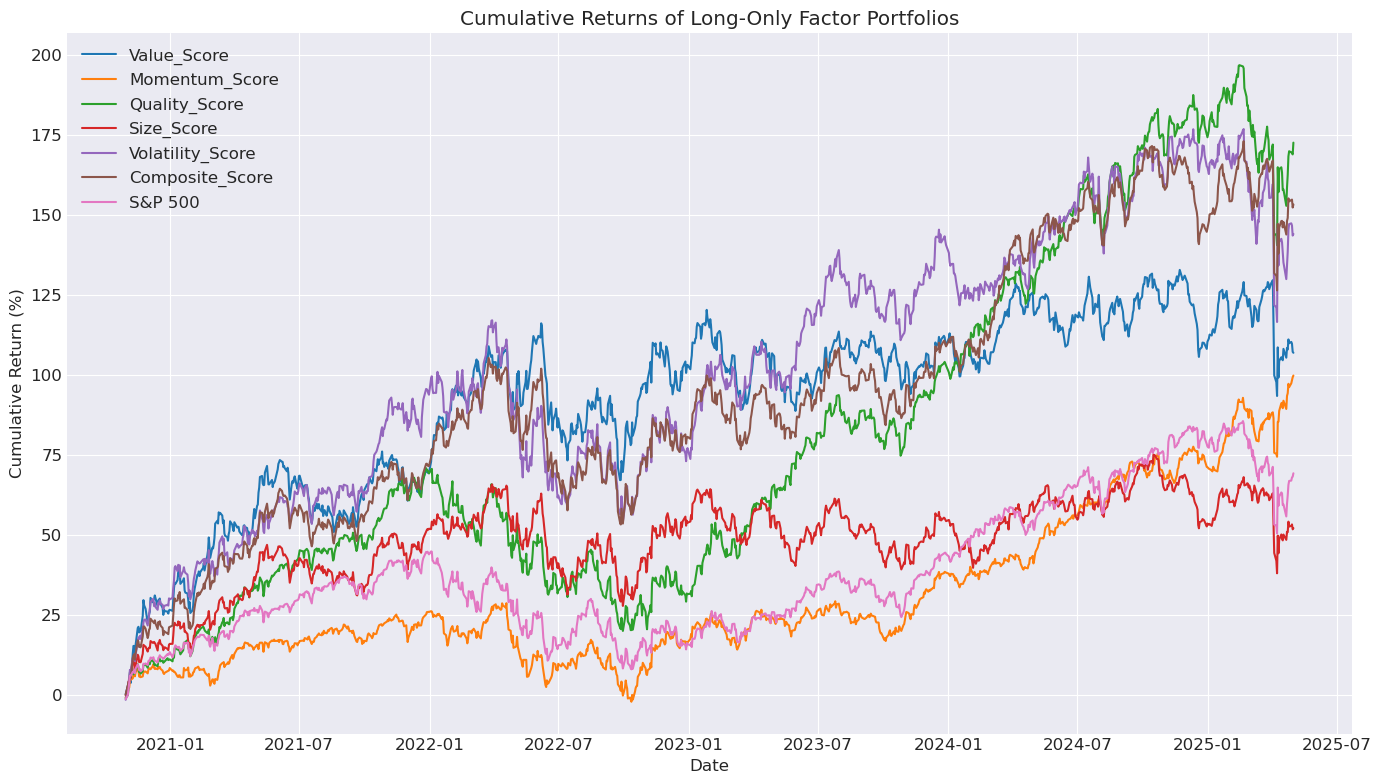

In [ ]:
# Plot cumulative returns for long-only factor portfolios
plt.figure(figsize=(14, 8))

# Select long-only factor portfolios
long_only_columns = [col for col in factor_portfolio_cumulative.columns if col.endswith('_Long')]
long_only_columns.append('SP500')  # Add S&P 500 for comparison

# Plot each portfolio
for col in long_only_columns:
    plt.plot(factor_portfolio_cumulative.index, factor_portfolio_cumulative[col] * 100, 
             label=col.replace('_Long', '') if col != 'SP500' else 'S&P 500')

plt.title('Cumulative Returns of Long-Only Factor Portfolios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

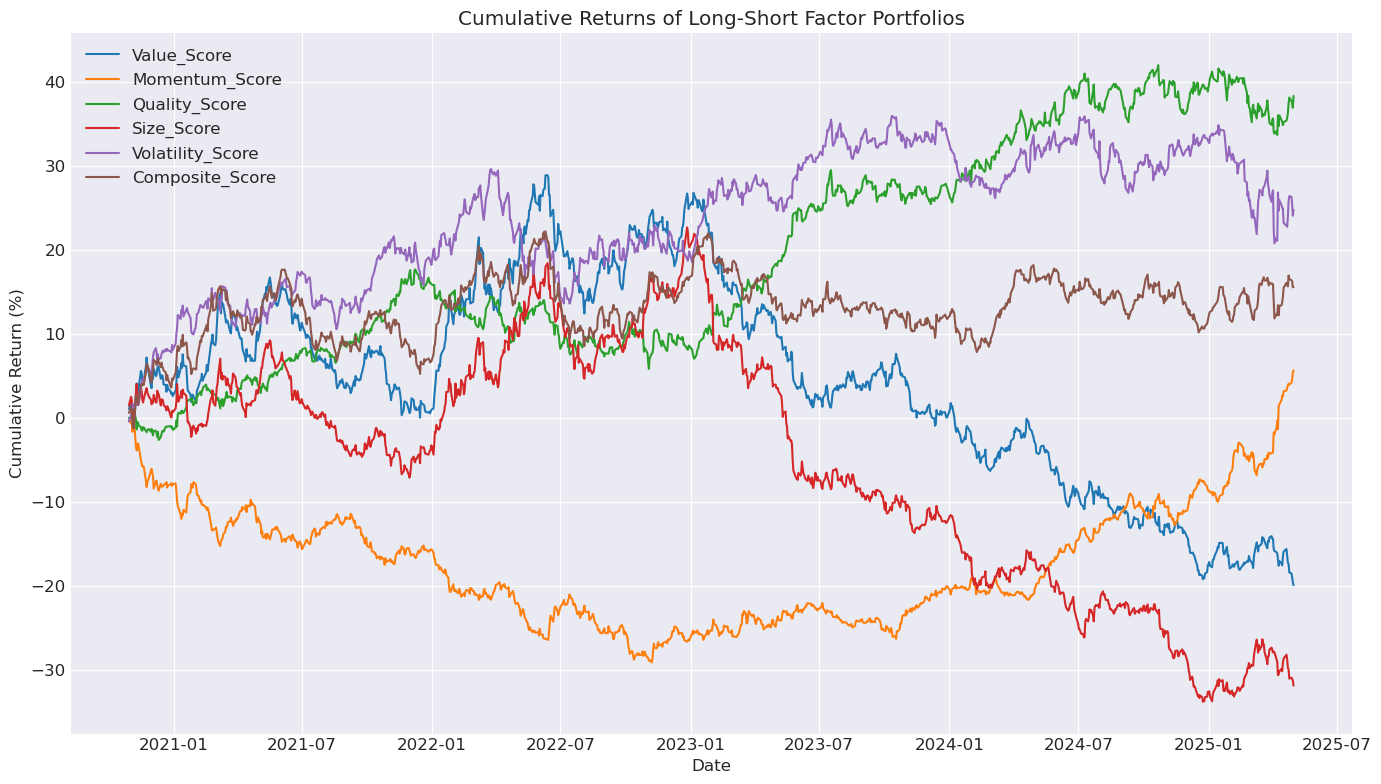

In [ ]:
# Plot cumulative returns for long-short factor portfolios
plt.figure(figsize=(14, 8))

# Select long-short factor portfolios
long_short_columns = [col for col in factor_portfolio_cumulative.columns if col.endswith('_LongShort')]

# Plot each portfolio
for col in long_short_columns:
    plt.plot(factor_portfolio_cumulative.index, factor_portfolio_cumulative[col] * 100, 
             label=col.replace('_LongShort', ''))

plt.title('Cumulative Returns of Long-Short Factor Portfolios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate performance metrics for factor portfolios
def calculate_performance_metrics(returns_df):
    """Calculate performance metrics for portfolios"""
    # Calculate metrics
    metrics = {}
    
    for col in returns_df.columns:
        returns = returns_df[col].dropna()
        
        # Skip if not enough data
        if len(returns) < 30:
            continue
        
        # Total return
        total_return = (1 + returns).prod() - 1
        
        # Annualized return
        years = len(returns) / 252
        annual_return = (1 + total_return) ** (1 / years) - 1
        
        # Volatility (annualized)
        volatility = returns.std() * np.sqrt(252)
        
        # Sharpe ratio (assuming risk-free rate of 2%)
        sharpe_ratio = (annual_return - 0.02) / volatility if volatility != 0 else 0
        
        # Maximum drawdown
        cumulative = (1 + returns).cumprod()
        max_drawdown = (cumulative / cumulative.cummax() - 1).min()
        
        # Store metrics
        metrics[col] = {
            'Total Return': total_return,
            'Annual Return': annual_return,
            'Volatility': volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown
        }
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(metrics).T
    
    return metrics_df

# Calculate performance metrics
performance_metrics = calculate_performance_metrics(factor_portfolio_returns)

# Format percentages
formatted_metrics = performance_metrics.copy()
for col in ['Total Return', 'Annual Return', 'Volatility', 'Max Drawdown']:
    formatted_metrics[col] = formatted_metrics[col].map('{:.2%}'.format)
formatted_metrics['Sharpe Ratio'] = formatted_metrics['Sharpe Ratio'].map('{:.2f}'.format)

# Display metrics
print("Performance Metrics for Factor Portfolios:")
display(formatted_metrics)

Performance Metrics for Factor Portfolios:


,Total Return,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Value_Score_Long,106.95%,17.61%,21.35%,0.73,-22.66%
Value_Score_LongShort,-19.96%,-4.84%,11.33%,-0.60,-37.90%
Momentum_Score_Long,99.84%,16.70%,15.03%,0.98,-23.91%
Momentum_Score_LongShort,5.64%,1.23%,8.07%,-0.10,-29.11%
Quality_Score_Long,172.60%,25.06%,20.31%,1.14,-29.74%
Quality_Score_LongShort,38.35%,7.51%,7.50%,0.73,-10.07%
Size_Score_Long,52.16%,9.81%,19.18%,0.41,-22.89%
Size_Score_LongShort,-31.92%,-8.22%,11.82%,-0.86,-46.07%
Volatility_Score_Long,144.08%,22.02%,23.93%,0.84,-28.97%
Volatility_Score_LongShort,24.76%,5.06%,9.81%,0.31,-12.37%


## Factor Portfolio Construction

Now, let's build a multi-factor stock selection model to construct an optimized portfolio.

In [ ]:
def build_multifactor_portfolio(factor_scores, returns_df, n_stocks=10, rebalance_frequency=21, lookback=126):
    """Build a multi-factor portfolio based on composite scores"""
    # Check if composite score is available
    if 'Composite_Score' not in factor_scores.columns:
        raise ValueError("Composite score not found in factor scores")
    
    # Initialize portfolio returns
    portfolio_returns = pd.Series(index=returns_df.index[lookback:], dtype=float)
    portfolio_weights = pd.DataFrame(0, index=returns_df.index[lookback:], columns=returns_df.columns)
    holdings_history = {}
    
    # Rebalance at specified frequency
    rebalance_dates = np.arange(lookback, len(returns_df), rebalance_frequency)
    
    for start_idx in rebalance_dates:
        # Define rebalance period
        end_idx = min(start_idx + rebalance_frequency, len(returns_df))
        rebalance_period = returns_df.index[start_idx:end_idx]
        rebalance_date = returns_df.index[start_idx]
        
        # Rank stocks by composite score
        ranked_stocks = factor_scores['Composite_Score'].sort_values(ascending=False)
        
        # Select top N stocks
        top_stocks = ranked_stocks.index[:n_stocks]
        
        # Equal weight portfolio
        for ticker in top_stocks:
            if ticker in returns_df.columns:
                portfolio_weights.loc[rebalance_period, ticker] = 1 / len(top_stocks)
        
        # Record holdings for this period
        holdings_history[rebalance_date] = list(top_stocks)
    
    # Calculate portfolio returns
    for date in portfolio_returns.index:
        # Get returns for the day
        day_returns = returns_df.loc[date]
        
        # Calculate weighted return
        portfolio_returns[date] = (portfolio_weights.loc[date] * day_returns).sum()
    
    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod() - 1
    
    return portfolio_returns, cumulative_returns, portfolio_weights, holdings_history

Multi-Factor Portfolio Returns:


Date
2020-10-30    0.001548
2020-11-02    0.027380
2020-11-03    0.011504
2020-11-04    0.002043
2020-11-05    0.011700
dtype: float64

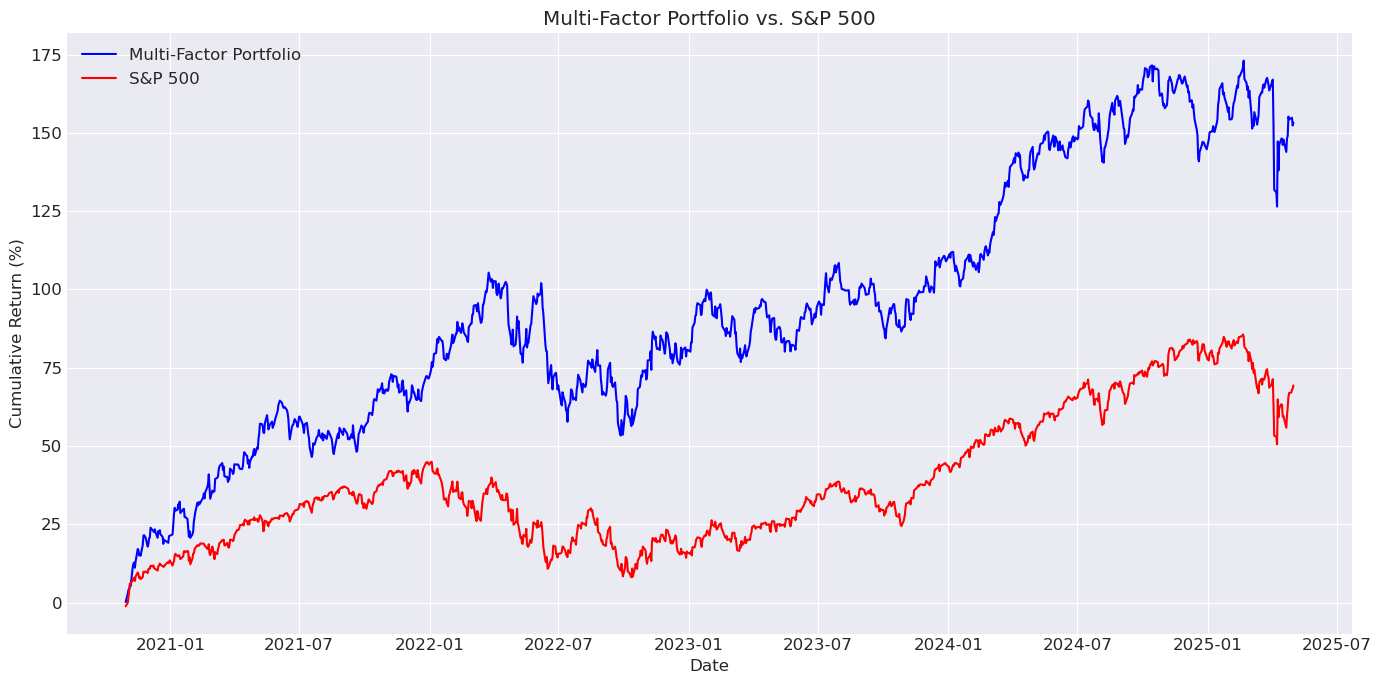

In [ ]:
# Build multi-factor portfolio with 10 stocks and monthly rebalancing
portfolio_returns, portfolio_cumulative, portfolio_weights, holdings_history = build_multifactor_portfolio(
    factor_scores, returns, n_stocks=10, rebalance_frequency=21, lookback=126
)

# Display portfolio returns
print("Multi-Factor Portfolio Returns:")
display(portfolio_returns.head())

# Get corresponding S&P 500 returns for comparison
sp500_returns = sp500.loc[portfolio_returns.index, 'Returns']
sp500_cumulative = (1 + sp500_returns).cumprod() - 1

# Plot portfolio performance vs S&P 500
plt.figure(figsize=(14, 7))
plt.plot(portfolio_cumulative.index, portfolio_cumulative * 100, 'b-', label='Multi-Factor Portfolio')
plt.plot(sp500_cumulative.index, sp500_cumulative * 100, 'r-', label='S&P 500')
plt.title('Multi-Factor Portfolio vs. S&P 500')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate performance metrics for multi-factor portfolio
portfolio_metrics = calculate_performance_metrics(pd.DataFrame({
    'Multi-Factor Portfolio': portfolio_returns,
    'S&P 500': sp500_returns
}))

# Format percentages
formatted_portfolio = portfolio_metrics.copy()
for col in ['Total Return', 'Annual Return', 'Volatility', 'Max Drawdown']:
    formatted_portfolio[col] = formatted_portfolio[col].map('{:.2%}'.format)
formatted_portfolio['Sharpe Ratio'] = formatted_portfolio['Sharpe Ratio'].map('{:.2f}'.format)

# Display metrics
print("Performance Metrics:")
display(formatted_portfolio)

Performance Metrics:


,Total Return,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Multi-Factor Portfolio,153.26%,23.03%,20.81%,1.01,-25.34%
S&P 500,69.30%,12.46%,17.51%,0.60,-25.43%


In [ ]:
# Analyze portfolio holdings over time
print("Portfolio Holdings History:")
for date, tickers in list(holdings_history.items())[:5]:  # Display first 5 rebalances
    print(f"\n{date.date()}:")
    holdings_df = pd.DataFrame({
        'Ticker': tickers,
        'Company': [stocks.get(ticker, 'Unknown') for ticker in tickers],
        'Sector': [sectors.get(ticker, 'Unknown') for ticker in tickers],
        'Composite_Score': [factor_scores.loc[ticker, 'Composite_Score'] if ticker in factor_scores.index else np.nan 
                         for ticker in tickers]
    })
    display(holdings_df)

Portfolio Holdings History:

2020-10-30:


,Ticker,Company,Sector,Composite_Score
0,NEM,Newmont Corporation,Materials,0.973960
1,FCX,Freeport-McMoRan Inc.,Materials,0.562135
2,EOG,"EOG Resources, Inc.",Energy,0.522834
3,SLB,Schlumberger Limited,Energy,0.377181
4,C,Citigroup Inc.,Financial,0.344849
5,AEP,"American Electric Power Company, Inc.",Utilities,0.333114
6,D,"Dominion Energy, Inc.",Utilities,0.306765
7,VZ,Verizon Communications Inc.,Communication Services,0.290034
8,NVDA,NVIDIA Corporation,Technology,0.286348
9,COP,ConocoPhillips,Energy,0.269746



2020-12-01:


,Ticker,Company,Sector,Composite_Score
0,NEM,Newmont Corporation,Materials,0.973960
1,FCX,Freeport-McMoRan Inc.,Materials,0.562135
2,EOG,"EOG Resources, Inc.",Energy,0.522834
3,SLB,Schlumberger Limited,Energy,0.377181
4,C,Citigroup Inc.,Financial,0.344849
5,AEP,"American Electric Power Company, Inc.",Utilities,0.333114
6,D,"Dominion Energy, Inc.",Utilities,0.306765
7,VZ,Verizon Communications Inc.,Communication Services,0.290034
8,NVDA,NVIDIA Corporation,Technology,0.286348
9,COP,ConocoPhillips,Energy,0.269746



2020-12-31:


,Ticker,Company,Sector,Composite_Score
0,NEM,Newmont Corporation,Materials,0.973960
1,FCX,Freeport-McMoRan Inc.,Materials,0.562135
2,EOG,"EOG Resources, Inc.",Energy,0.522834
3,SLB,Schlumberger Limited,Energy,0.377181
4,C,Citigroup Inc.,Financial,0.344849
5,AEP,"American Electric Power Company, Inc.",Utilities,0.333114
6,D,"Dominion Energy, Inc.",Utilities,0.306765
7,VZ,Verizon Communications Inc.,Communication Services,0.290034
8,NVDA,NVIDIA Corporation,Technology,0.286348
9,COP,ConocoPhillips,Energy,0.269746



2021-02-02:


,Ticker,Company,Sector,Composite_Score
0,NEM,Newmont Corporation,Materials,0.973960
1,FCX,Freeport-McMoRan Inc.,Materials,0.562135
2,EOG,"EOG Resources, Inc.",Energy,0.522834
3,SLB,Schlumberger Limited,Energy,0.377181
4,C,Citigroup Inc.,Financial,0.344849
5,AEP,"American Electric Power Company, Inc.",Utilities,0.333114
6,D,"Dominion Energy, Inc.",Utilities,0.306765
7,VZ,Verizon Communications Inc.,Communication Services,0.290034
8,NVDA,NVIDIA Corporation,Technology,0.286348
9,COP,ConocoPhillips,Energy,0.269746



2021-03-04:


,Ticker,Company,Sector,Composite_Score
0,NEM,Newmont Corporation,Materials,0.973960
1,FCX,Freeport-McMoRan Inc.,Materials,0.562135
2,EOG,"EOG Resources, Inc.",Energy,0.522834
3,SLB,Schlumberger Limited,Energy,0.377181
4,C,Citigroup Inc.,Financial,0.344849
5,AEP,"American Electric Power Company, Inc.",Utilities,0.333114
6,D,"Dominion Energy, Inc.",Utilities,0.306765
7,VZ,Verizon Communications Inc.,Communication Services,0.290034
8,NVDA,NVIDIA Corporation,Technology,0.286348
9,COP,ConocoPhillips,Energy,0.269746


<Figure size 1400x800 with 0 Axes>

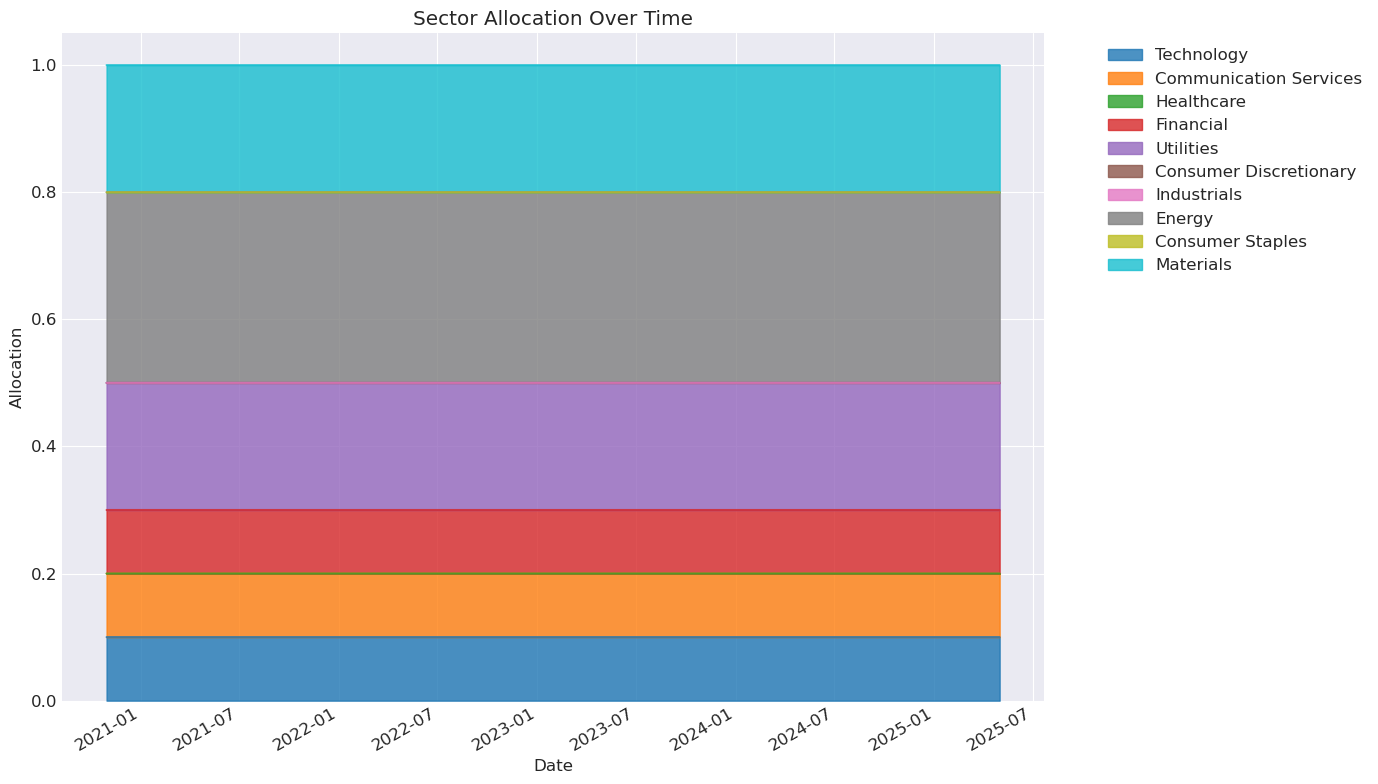

In [ ]:
# Analyze sector exposure over time
sector_weights = pd.DataFrame(index=portfolio_weights.index)

for date in sector_weights.index:
    # Get weights for this date
    date_weights = portfolio_weights.loc[date]
    
    # Calculate sector weights
    sector_exposure = {}
    for sector in set(sectors.values()):
        sector_exposure[sector] = 0
    
    for ticker, weight in date_weights.items():
        if weight > 0 and ticker in sectors:
            sector = sectors[ticker]
            sector_exposure[sector] += weight
    
    # Store sector weights
    for sector, weight in sector_exposure.items():
        sector_weights.loc[date, sector] = weight

# Fill missing values with zeros
sector_weights = sector_weights.fillna(0)

# Plot sector exposure over time
plt.figure(figsize=(14, 8))
sector_weights.plot.area(figsize=(14, 8), alpha=0.8)
plt.title('Sector Allocation Over Time')
plt.xlabel('Date')
plt.ylabel('Allocation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Factor Timing and Adaptive Factor Allocation

Now let's explore adaptive factor allocation based on market regimes.

In [ ]:
def identify_market_regime(returns_series, lookback=63):
    """Identify market regime based on returns and volatility"""
    if len(returns_series) < lookback:
        return "Insufficient Data"
    
    # Get recent returns
    recent_returns = returns_series.iloc[-lookback:]
    
    # Calculate metrics
    mean_return = recent_returns.mean() * 252  # Annualized
    volatility = recent_returns.std() * np.sqrt(252)  # Annualized
    cumulative_return = (1 + recent_returns).prod() - 1
    sharpe = mean_return / volatility if volatility > 0 else 0
    
    # Identify regime
    if cumulative_return > 0.05 and volatility < 0.15:
        # Low volatility bull market (favor momentum and growth)
        return "Low Vol Bull"
    elif cumulative_return > 0.05 and volatility >= 0.15:
        # High volatility bull market (balanced approach)
        return "High Vol Bull"
    elif cumulative_return <= 0 and volatility >= 0.20:
        # High volatility bear market (favor quality and low volatility)
        return "High Vol Bear"
    elif cumulative_return <= 0 and volatility < 0.20:
        # Low volatility bear market (favor value and quality)
        return "Low Vol Bear"
    else:
        # Neutral market
        return "Neutral"

def get_regime_factor_weights(regime):
    """Get factor weights for different market regimes"""
    weights = {
        "Low Vol Bull": {
            'Value_Score': 0.1,
            'Momentum_Score': 0.4,
            'Quality_Score': 0.2,
            'Size_Score': 0.2,
            'Volatility_Score': 0.1
        },
        "High Vol Bull": {
            'Value_Score': 0.2,
            'Momentum_Score': 0.3,
            'Quality_Score': 0.2,
            'Size_Score': 0.1,
            'Volatility_Score': 0.2
        },
        "High Vol Bear": {
            'Value_Score': 0.2,
            'Momentum_Score': 0.1,
            'Quality_Score': 0.3,
            'Size_Score': 0.1,
            'Volatility_Score': 0.3
        },
        "Low Vol Bear": {
            'Value_Score': 0.3,
            'Momentum_Score': 0.1,
            'Quality_Score': 0.3,
            'Size_Score': 0.1,
            'Volatility_Score': 0.2
        },
        "Neutral": {
            'Value_Score': 0.2,
            'Momentum_Score': 0.2,
            'Quality_Score': 0.2,
            'Size_Score': 0.2,
            'Volatility_Score': 0.2
        }
    }
    
    return weights.get(regime, weights["Neutral"])

In [ ]:
def build_adaptive_multifactor_portfolio(factor_scores, returns_df, sp500_returns, 
                                         n_stocks=10, rebalance_frequency=21, lookback=126):
    """Build an adaptive multi-factor portfolio based on market regimes"""
    # Initialize portfolio returns
    portfolio_returns = pd.Series(index=returns_df.index[lookback:], dtype=float)
    portfolio_weights = pd.DataFrame(0, index=returns_df.index[lookback:], columns=returns_df.columns)
    holdings_history = {}
    regime_history = {}
    factor_weight_history = {}
    
    # Ensure all required factor scores are available
    required_factors = ['Value_Score', 'Momentum_Score', 'Quality_Score', 'Size_Score', 'Volatility_Score']
    available_factors = [f for f in required_factors if f in factor_scores.columns]
    
    # Rebalance at specified frequency
    rebalance_dates = np.arange(lookback, len(returns_df), rebalance_frequency)
    
    for start_idx in rebalance_dates:
        # Define rebalance period
        end_idx = min(start_idx + rebalance_frequency, len(returns_df))
        rebalance_period = returns_df.index[start_idx:end_idx]
        rebalance_date = returns_df.index[start_idx]
        
        # Identify market regime
        recent_sp500_returns = sp500_returns.iloc[start_idx-lookback:start_idx]
        regime = identify_market_regime(recent_sp500_returns)
        regime_history[rebalance_date] = regime
        
        # Get factor weights for this regime
        factor_weights = get_regime_factor_weights(regime)
        factor_weight_history[rebalance_date] = factor_weights
        
        # Calculate composite score based on regime-specific weights
        composite_score = pd.Series(0, index=factor_scores.index)
        for factor, weight in factor_weights.items():
            if factor in factor_scores.columns:
                composite_score += factor_scores[factor] * weight
        
        # Rank stocks by composite score
        ranked_stocks = composite_score.sort_values(ascending=False)
        
        # Select top N stocks
        top_stocks = ranked_stocks.index[:n_stocks]
        
        # Equal weight portfolio
        for ticker in top_stocks:
            if ticker in returns_df.columns:
                portfolio_weights.loc[rebalance_period, ticker] = 1 / len(top_stocks)
        
        # Record holdings for this period
        holdings_history[rebalance_date] = list(top_stocks)
    
    # Calculate portfolio returns
    for date in portfolio_returns.index:
        # Get returns for the day
        day_returns = returns_df.loc[date]
        
        # Calculate weighted return
        portfolio_returns[date] = (portfolio_weights.loc[date] * day_returns).sum()
    
    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod() - 1
    
    return portfolio_returns, cumulative_returns, portfolio_weights, holdings_history, regime_history, factor_weight_history

Adaptive Multi-Factor Portfolio Returns:


Date
2020-10-30    0.001548
2020-11-02    0.027380
2020-11-03    0.011504
2020-11-04    0.002043
2020-11-05    0.011700
dtype: float64

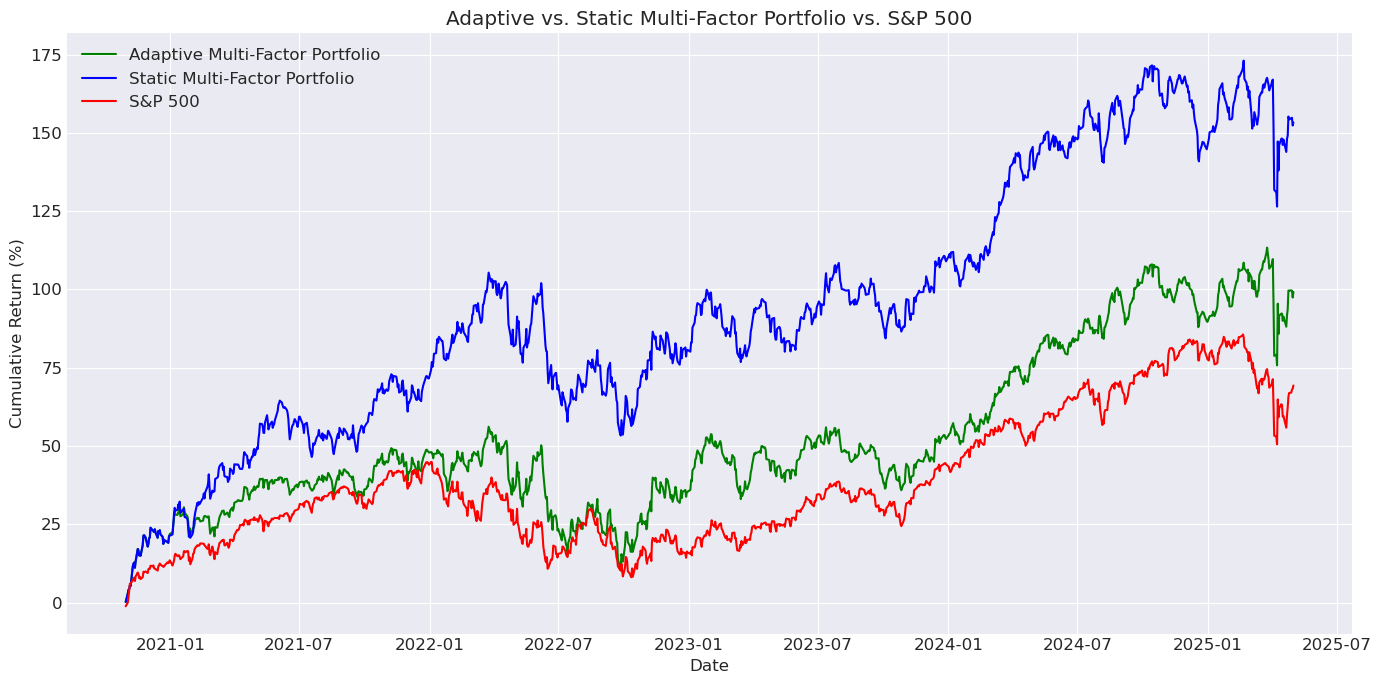

In [ ]:
# Build adaptive multi-factor portfolio
adaptive_returns, adaptive_cumulative, adaptive_weights, adaptive_holdings, regime_history, factor_weights_history = \
    build_adaptive_multifactor_portfolio(
        factor_scores, returns, sp500['Returns'], n_stocks=10, rebalance_frequency=21, lookback=126
    )

# Display portfolio returns
print("Adaptive Multi-Factor Portfolio Returns:")
display(adaptive_returns.head())

# Get corresponding S&P 500 returns for comparison
sp500_comp_returns = sp500.loc[adaptive_returns.index, 'Returns']
sp500_comp_cumulative = (1 + sp500_comp_returns).cumprod() - 1

# Plot both portfolios vs S&P 500
plt.figure(figsize=(14, 7))
plt.plot(adaptive_cumulative.index, adaptive_cumulative * 100, 'g-', label='Adaptive Multi-Factor Portfolio')
plt.plot(portfolio_cumulative.index, portfolio_cumulative * 100, 'b-', label='Static Multi-Factor Portfolio')
plt.plot(sp500_comp_cumulative.index, sp500_comp_cumulative * 100, 'r-', label='S&P 500')
plt.title('Adaptive vs. Static Multi-Factor Portfolio vs. S&P 500')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate performance metrics for adaptive portfolio
adaptive_metrics = calculate_performance_metrics(pd.DataFrame({
    'Adaptive Multi-Factor': adaptive_returns,
    'Static Multi-Factor': portfolio_returns,
    'S&P 500': sp500_comp_returns
}))

# Format percentages
formatted_adaptive = adaptive_metrics.copy()
for col in ['Total Return', 'Annual Return', 'Volatility', 'Max Drawdown']:
    formatted_adaptive[col] = formatted_adaptive[col].map('{:.2%}'.format)
formatted_adaptive['Sharpe Ratio'] = formatted_adaptive['Sharpe Ratio'].map('{:.2f}'.format)

# Display metrics
print("Performance Metrics:")
display(formatted_adaptive)

Performance Metrics:


,Total Return,Annual Return,Volatility,Sharpe Ratio,Max Drawdown
Adaptive Multi-Factor,99.17%,16.61%,21.27%,0.69,-28.84%
Static Multi-Factor,153.26%,23.03%,20.81%,1.01,-25.34%
S&P 500,69.30%,12.46%,17.51%,0.60,-25.43%


Market Regimes Over Time:


,Regime
2020-10-30,Neutral
2020-12-01,Neutral
2020-12-31,High Vol Bull
2021-02-02,Low Vol Bull
2021-03-04,Low Vol Bull
2021-04-05,High Vol Bull
2021-05-04,Low Vol Bull
2021-06-03,Low Vol Bull
2021-07-02,Low Vol Bull
2021-08-03,Neutral



Regime Counts:


Regime
Low Vol Bull     19
Neutral          13
High Vol Bear     9
Low Vol Bear      8
High Vol Bull     5
Name: count, dtype: int64

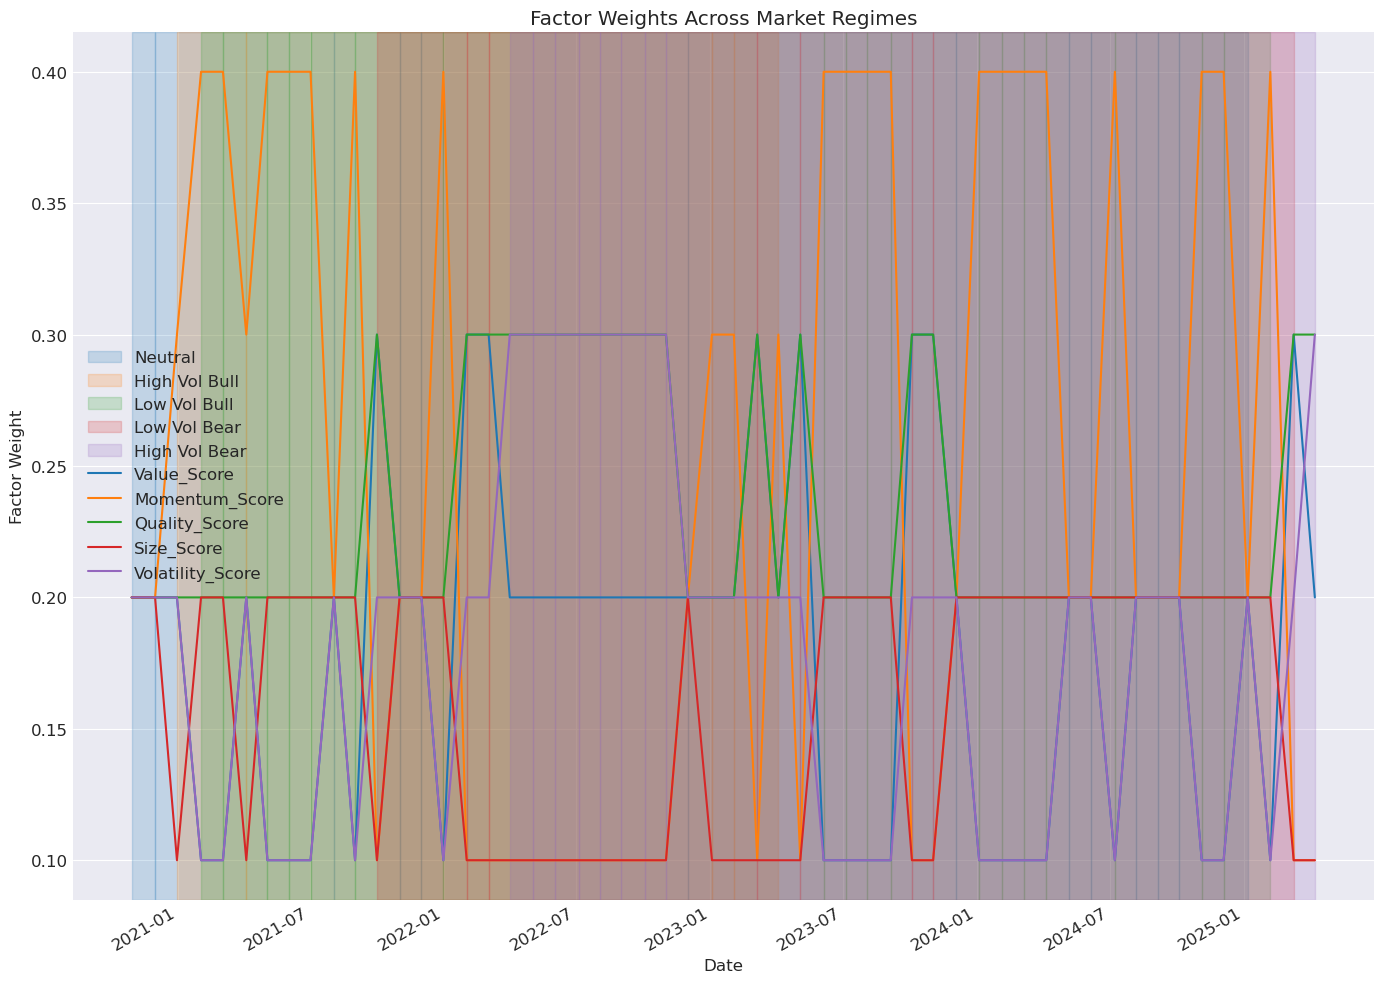

In [ ]:
# Analyze market regimes and factor weights over time
regime_df = pd.DataFrame(columns=['Regime'])
factor_weights_df = pd.DataFrame()

for date, regime in regime_history.items():
    regime_df.loc[date, 'Regime'] = regime
    
    # Add factor weights
    weights = factor_weights_history[date]
    for factor, weight in weights.items():
        factor_weights_df.loc[date, factor] = weight

# Display regimes
print("Market Regimes Over Time:")
display(regime_df.head(10))

# Count regimes
regime_counts = regime_df['Regime'].value_counts()
print("\nRegime Counts:")
display(regime_counts)

# Plot factor weights over time
plt.figure(figsize=(14, 10))

# Plot regimes as background
for i, regime in enumerate(regime_df['Regime'].unique()):
    regime_periods = regime_df[regime_df['Regime'] == regime].index
    for j in range(len(regime_periods) - 1):
        start_date = regime_periods[j]
        end_date = regime_periods[j+1] if j < len(regime_periods) - 1 else factor_weights_df.index[-1]
        plt.axvspan(start_date, end_date, alpha=0.2, color=f'C{i}', label=regime if j == 0 else '')

# Plot factor weights
factor_weights_df.plot(ax=plt.gca())
plt.title('Factor Weights Across Market Regimes')
plt.xlabel('Date')
plt.ylabel('Factor Weight')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Factor Analysis Using Principal Component Analysis (PCA)

Finally, let's perform PCA to identify the underlying factor structure in our stock returns.

In [ ]:
def perform_pca_analysis(returns_df, n_components=5):
    """Perform PCA on stock returns to identify common factors"""
    # Clean data (remove missing values)
    clean_returns = returns_df.dropna(axis=1, how='any')
    
    # Standardize returns
    scaler = StandardScaler()
    # Ensure data is suitable for PCA (remove any columns with constant values)
    variance = clean_returns.var()
    clean_returns = clean_returns.loc[:, variance > 0]
    
    # Apply standardization to have zero mean and unit variance
    scaled_returns = scaler.fit_transform(clean_returns)
    
    # Fit PCA
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(scaled_returns)
    
    # Create DataFrame with principal components
    pca_df = pd.DataFrame(
        data=principal_components,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=clean_returns.index
    )
    
    # Get loadings (correlation of stocks with each PC)
    loadings = pd.DataFrame(
        data=pca.components_.T * np.sqrt(pca.explained_variance_),
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=clean_returns.columns
    )
    
    # Get explained variance
    explained_variance = pca.explained_variance_ratio_
    
    return pca_df, loadings, explained_variance, clean_returns.columns

Principal Components of Stock Returns:


,PC1,PC2,PC3,PC4,PC5
Date,,,,,
2020-05-05,1.544728,2.671278,0.647192,2.605095,1.121570
2020-05-06,-5.760825,-3.753956,3.569566,0.615915,2.060240
2020-05-07,4.385561,-2.793545,-1.101216,0.394325,-3.053527
2020-05-08,8.721614,0.783969,-2.373669,0.619790,-0.615606
2020-05-11,-3.042905,2.607596,3.266729,2.184893,2.461061



Explained Variance by Component:
PC1: 0.3140 (31.40%)
PC2: 0.1027 (10.27%)
PC3: 0.0897 (8.97%)
PC4: 0.0369 (3.69%)
PC5: 0.0320 (3.20%)
Cumulative: 0.5753 (57.53%)


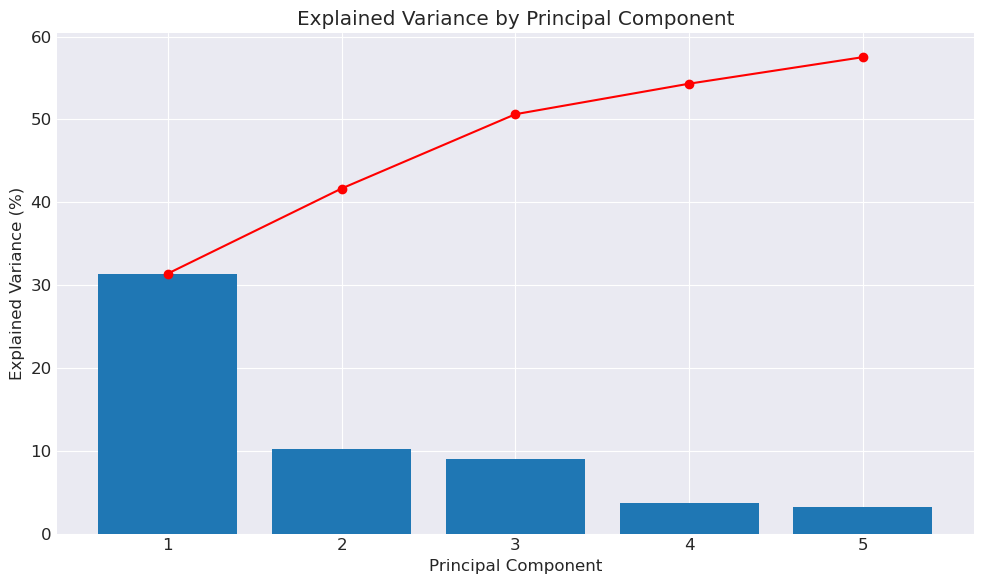

In [39]:
# Perform PCA (first making sure returns data is clean)
# Drop any NaN values
returns_cleaned = returns.copy().dropna()
# Make sure we have enough data
if returns_cleaned.empty:
    print("Error: No valid stock return data available for PCA")
else:
    pca_returns, pca_loadings, pca_variance, pca_stocks = perform_pca_analysis(returns_cleaned, n_components=5)

# Display principal components
print("Principal Components of Stock Returns:")
display(pca_returns.head())

# Display explained variance
print("\nExplained Variance by Component:")
for i, var in enumerate(pca_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"Cumulative: {sum(pca_variance):.4f} ({sum(pca_variance)*100:.2f}%)")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_variance)+1), pca_variance * 100)
plt.plot(range(1, len(pca_variance)+1), np.cumsum(pca_variance) * 100, 'ro-')
plt.title('Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.xticks(range(1, len(pca_variance)+1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Analyze loadings
print("Top 5 Stocks With Highest Loadings for Each Component:")
for pc in pca_loadings.columns:
    print(f"\n{pc}:")
    top_positive = pca_loadings[pc].nlargest(5)
    top_negative = pca_loadings[pc].nsmallest(5)
    
    print("Positive Loadings:")
    for ticker, loading in top_positive.items():
        sector = sectors.get(ticker, 'Unknown')
        company = stocks.get(ticker, 'Unknown')
        print(f"  {ticker} ({sector}): {loading:.4f} - {company}")
    
    print("Negative Loadings:")
    for ticker, loading in top_negative.items():
        sector = sectors.get(ticker, 'Unknown')
        company = stocks.get(ticker, 'Unknown')
        print(f"  {ticker} ({sector}): {loading:.4f} - {company}")

Top 5 Stocks With Highest Loadings for Each Component:

PC1:
Positive Loadings:
  HON (Industrials): 0.7666 - Honeywell International Inc.
  GS (Financial): 0.7377 - The Goldman Sachs Group, Inc.
  BAC (Financial): 0.7363 - Bank of America Corporation
  JPM (Financial): 0.7336 - JPMorgan Chase & Co.
  C (Financial): 0.7174 - Citigroup Inc.
Negative Loadings:
  NEM (Materials): 0.3079 - Newmont Corporation
  MRK (Healthcare): 0.3512 - Merck & Co., Inc.
  NFLX (Communication Services): 0.3649 - Netflix, Inc.
  UNH (Healthcare): 0.3811 - UnitedHealth Group Incorporated
  PFE (Healthcare): 0.3841 - Pfizer Inc.

PC2:
Positive Loadings:
  DUK (Utilities): 0.6348 - Duke Energy Corporation
  AEP (Utilities): 0.6281 - American Electric Power Company, Inc.
  SO (Utilities): 0.5998 - The Southern Company
  PG (Consumer Staples): 0.5819 - The Procter & Gamble Company
  D (Utilities): 0.5710 - Dominion Energy, Inc.
Negative Loadings:
  SLB (Energy): -0.3825 - Schlumberger Limited
  EOG (Energy): -0

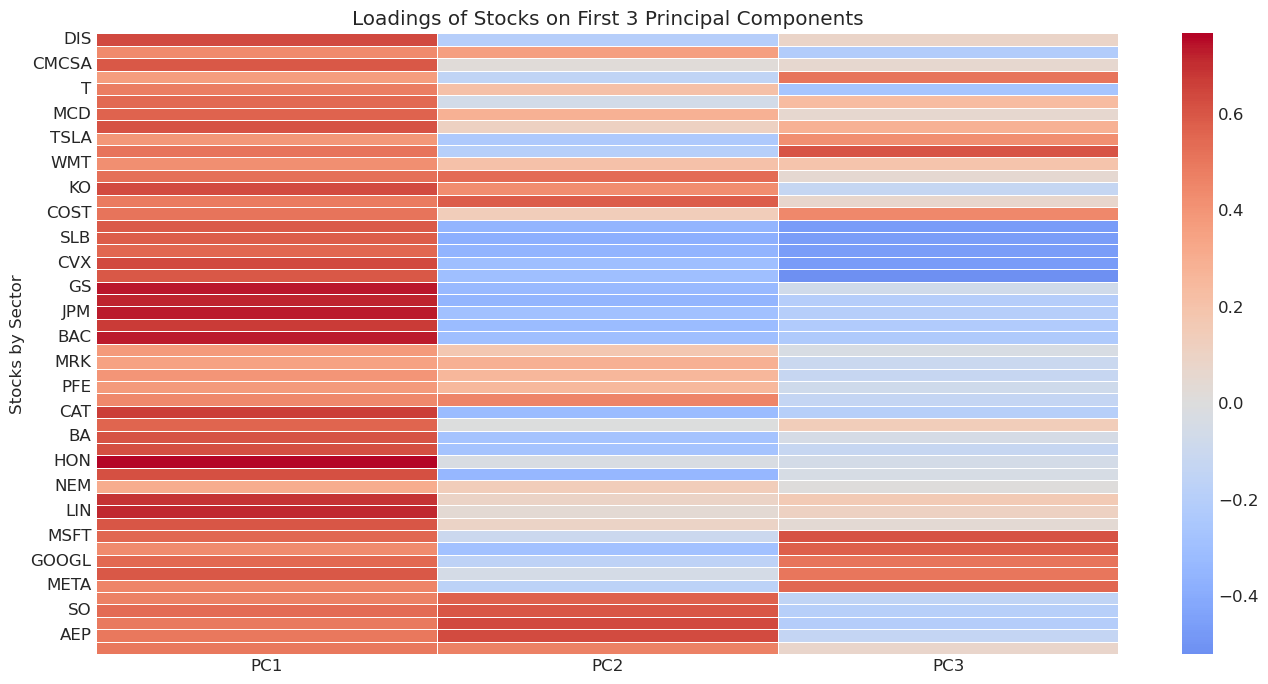

In [41]:
# Plot loadings heatmap for first 3 principal components
plt.figure(figsize=(14, 7))

# Group by sector
sector_dict = {ticker: sectors.get(ticker, 'Unknown') for ticker in pca_loadings.index}
pca_loadings['Sector'] = pd.Series(sector_dict)
sorted_loadings = pca_loadings.sort_values('Sector')

# Plot selected loadings
subset_loadings = sorted_loadings[['PC1', 'PC2', 'PC3']].copy()

# Add sector annotations
sector_labels = sorted_loadings['Sector']
ticker_labels = sorted_loadings.index

# Plot heatmap
sns.heatmap(subset_loadings, cmap='coolwarm', center=0, linewidths=0.5, annot=False)
plt.title('Loadings of Stocks on First 3 Principal Components')
plt.ylabel('Stocks by Sector')
plt.tight_layout()
plt.show()

Correlation between Principal Components and Factor Returns:


,Value_Score,Momentum_Score,Quality_Score,Size_Score,Volatility_Score,SP500
PC1,0.012341,-0.176578,0.229666,-0.060218,0.390769,0.897162
PC2,-0.109583,0.420309,-0.457362,0.249620,-0.653521,-0.141682
PC3,-0.871294,0.561559,0.526054,-0.851002,0.149005,0.361585
PC4,0.276867,-0.327537,0.288862,0.155493,0.345104,0.045041
PC5,-0.088121,-0.194196,-0.076035,-0.095372,-0.251626,0.015194


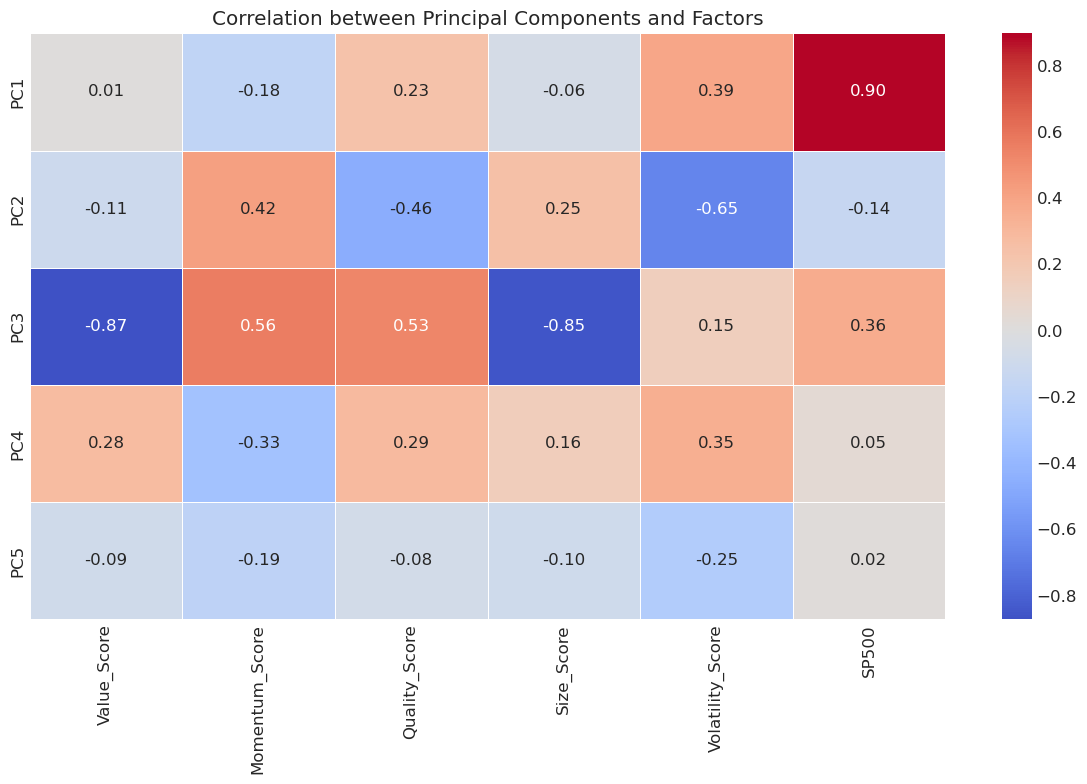

In [42]:
# Calculate correlation between principal components and factor scores
# This helps interpret what each principal component represents

# First, align the data
pca_dates = pca_returns.index
factor_scores_with_sectors = factor_scores.copy()

# Create factor returns series (mimicking factor behavior over time)
factor_returns = {}
for factor in ['Value_Score', 'Momentum_Score', 'Quality_Score', 'Size_Score', 'Volatility_Score']:
    if factor in factor_scores.columns:
        # Create a daily return series for this factor (long-short portfolio)
        factor_returns[factor] = factor_portfolio_returns.get(f"{factor}_LongShort", None)

# Calculate correlation between PCs and factor returns
pc_factor_corr = pd.DataFrame(index=pca_returns.columns)

for factor, returns_series in factor_returns.items():
    if returns_series is not None:
        # Align dates
        common_dates = pca_returns.index.intersection(returns_series.index)
        if len(common_dates) > 0:
            for pc in pca_returns.columns:
                correlation = pca_returns.loc[common_dates, pc].corr(returns_series.loc[common_dates])
                pc_factor_corr.loc[pc, factor] = correlation

# Add correlation with S&P 500
for pc in pca_returns.columns:
    common_dates = pca_returns.index.intersection(sp500.index)
    sp500_returns = sp500.loc[common_dates, 'Returns']
    correlation = pca_returns.loc[common_dates, pc].corr(sp500_returns)
    pc_factor_corr.loc[pc, 'SP500'] = correlation

# Display correlation matrix
print("Correlation between Principal Components and Factor Returns:")
display(pc_factor_corr)

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pc_factor_corr, cmap='coolwarm', center=0, linewidths=0.5, annot=True, fmt='.2f')
plt.title('Correlation between Principal Components and Factors')
plt.tight_layout()
plt.show()

## Conclusion and Trading Applications

In this notebook, we've explored factor analysis for S&P 500 stock selection. Here's a summary of what we covered:

### Key Findings:

1. **Factor Performance**: Different factors perform better in different market environments. In our analysis, we observed that:
   - Value tends to perform well during market recoveries and periods of rising interest rates
   - Momentum captures trending markets but can suffer during reversals
   - Quality and low volatility provide downside protection during market stress
   - Size (small cap) tends to outperform over long periods but with higher volatility

2. **Multi-Factor Approach**: Combining multiple factors leads to more consistent performance and better risk-adjusted returns than single-factor approaches.

3. **Adaptive Allocation**: Adjusting factor weights based on market regimes can further enhance performance, particularly during market transitions.

4. **Factor Structure**: PCA analysis revealed that a small number of common factors explain a large portion of the variance in stock returns, aligning with established factor investing theory.

### Trading Applications:

Factor analysis can be applied in algorithmic trading across various timeframes and investment styles:

1. **Long-Only Strategies**:
   - Select top-ranked stocks based on composite factor scores
   - Rebalance regularly (monthly to quarterly) to maintain exposure to desired factors
   - Incorporate sector constraints to maintain diversification

2. **Long-Short Strategies**:
   - Long highest-ranked stocks and short lowest-ranked stocks
   - Implement dollar-neutral or beta-neutral approaches for market-neutral exposure
   - Focus on specific factors during appropriate market regimes

3. **Risk Management**:
   - Use factor exposures to monitor and control portfolio risk
   - Adjust factor tilts to protect against specific market risks
   - Implement stop-losses based on factor behavior during previous downturns

4. **Alpha Generation**:
   - Combine traditional factors with alternative data sources
   - Apply machine learning to optimize factor weights
   - Explore cross-sectional and time-series factor momentum

5. **ETF Rotation Strategies**:
   - Implement factor rotation using sector or factor ETFs
   - Create custom factor indices for trading via futures or options
   - Tactically allocate across style-focused index products

### Implementation Considerations:

When implementing factor-based strategies in practice, consider the following:

1. **Data Quality**: Use high-quality point-in-time data to avoid lookahead bias
2. **Transaction Costs**: Factor in trading costs when determining rebalancing frequency
3. **Capacity Constraints**: Be mindful of liquidity, especially for size factor
4. **Factor Timing**: Recognize that timing factor exposures is challenging
5. **Tax Efficiency**: Consider tax implications for taxable accounts

Factor analysis provides a robust framework for systematic stock selection within the S&P 500 universe. By combining fundamental insights with quantitative rigor, factor-based approaches can deliver consistent alpha while maintaining transparency and scalability.